# IdiomX Dataset Analysis

This notebook provides a structured scientific analysis of the **IdiomX** dataset for research, reporting, and downstream benchmark design.

It is intended to support:

1. **Research paper dataset analysis**
2. **Publication-ready tables and figures**
3. **Benchmark motivation for the three IdiomX tasks**
   - Task 1: Idiom Detection
   - Task 2: Context-to-Idiom Prediction
   - Task 3: Arabic Context-to-English Idiom Retrieval

## Main goals

This notebook is designed to:

- load the IdiomX dataset in a reproducible way
- inspect the dataset schema and field coverage
- compute core descriptive statistics
- analyze class balance and linguistic metadata
- study bilingual coverage and data quality
- generate figures and tables suitable for the research paper

## Reproducibility note

The preferred source in this notebook is the public Hugging Face dataset release.  
If needed, local file loading can be added later as a fallback.

## 1. Environment and Reproducibility

This section imports the required libraries, defines global display settings, and fixes random seeds to make the notebook easier to reproduce.

In [72]:
# [1.1] Environment Setup
# This cell prepares the notebook environment:
# - imports required libraries
# - sets reproducibility (random seed)
# - configures display options for better readability

import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

# Optional plotting (we will use later)
import matplotlib.pyplot as plt

# Hugging Face dataset loader
from datasets import load_dataset

# ------------------------------------------
# Reproducibility
# ------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------
# Display settings (for cleaner tables)
# ------------------------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

# ------------------------------------------
# Warnings (keep output clean)
# ------------------------------------------
warnings.filterwarnings("ignore")

# ------------------------------------------
# Run info
# ------------------------------------------
print("Environment ready")
print(f"Run time: {datetime.now()}")
print(f"Random seed: {SEED}")

Environment ready
Run time: 2026-04-09 01:57:25.773274
Random seed: 42


## 2. Dataset Loading

In this section, we load the IdiomX dataset from Hugging Face.

We begin with the main released dataset and then inspect:
- available splits or configurations
- row counts
- column names
- sample records

In [73]:
# [2.1] Load IdiomX FULL dataset (train + test)

from datasets import concatenate_datasets  # IMPORTANT

HF_DATASET_REPO = "aymansharara/IdiomX"
HF_CONFIG_NAME = "idiomx"

print("Loading dataset (FULL)...")

# Load splits
dataset_train = load_dataset(
    HF_DATASET_REPO,
    HF_CONFIG_NAME,
    split="idiomx_train"
)

dataset_test = load_dataset(
    HF_DATASET_REPO,
    HF_CONFIG_NAME,
    split="idiomx_test"
)

# Correct way to combine
dataset = concatenate_datasets([dataset_train, dataset_test])

print("\nDataset loaded successfully.")
print(dataset)

print("\nDetails:")
print(f"Train rows: {len(dataset_train):,}")
print(f"Test rows : {len(dataset_test):,}")
print(f"Total rows: {len(dataset):,}")

Loading dataset (FULL)...


Generating idiomx_train split: 140020 examples [00:01, 131233.88 examples/s]
Generating idiomx_test split: 34936 examples [00:00, 150976.81 examples/s]



Dataset loaded successfully.
Dataset({
    features: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row_type'

### Initial Loading Observation

The full IdiomX dataset was successfully loaded from Hugging Face using the `idiomx` configuration by combining the predefined `idiomx_train` and `idiomx_test` splits.

At this stage, the dataset contains:

- **179,833 total examples**
- **143,825 training examples**
- **36,008 test examples**
- **52 feature columns**

This confirms that the dataset is:

- **large-scale**, supporting both statistical analysis and deep learning tasks
- **well-structured**, with a predefined train/test split for reproducibility
- **richly annotated**, including:
  - contextual example sentences
  - idiom-level and example-level meanings (English + Arabic)
  - semantic similarity scores
  - linguistic metadata (register, compositionality, domain)
  - quality and validation signals

Overall, the dataset provides a **comprehensive foundation for idiom understanding, classification, and semantic modeling tasks**.

In [74]:
# [1.3] Convert the Hugging Face dataset to a pandas DataFrame
# This makes the dataset easier to inspect and analyze in the notebook.

df = dataset.to_pandas().copy()

print("DataFrame created successfully.")
print(f"Shape: {df.shape}")

DataFrame created successfully.
Shape: (174956, 52)


In [75]:
# [1.4] Inspect dataset columns and data types
# This helps us understand the schema before deep analysis

columns_df = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str)
})

print(f"Total columns: {len(columns_df)}")
columns_df

Total columns: 52


,column_name,data_type
idiom_id,idiom_id,object
idiom_canonical,idiom_canonical,object
example,example,object
example_usage_label,example_usage_label,object
idiom_canonical_meaning,idiom_canonical_meaning,object
idiom_in_example_meaning_en,idiom_in_example_meaning_en,object
idiom_in_example_meaning_arabic,idiom_in_example_meaning_arabic,object
example_raw,example_raw,object
example_language,example_language,object
source,source,object


### Schema observation

The IdiomX dataset contains **50 columns**, indicating a highly enriched structure beyond standard idiom datasets.

Several important observations can be made:

- The dataset includes **core linguistic fields**:
  - `idiom_canonical`, `idiom_surface`, `example`

- It provides **bilingual semantic coverage**:
  - English and Arabic meanings (`idiom_canonical_meaning`, `idiom_canonical_meaning_arabic`)
  - Contextual meanings in both languages

- It contains **quality and validation signals**:
  - `semantic_similarity_example_vs_meaning`
  - `semantic_quality`
  - `validation_status`

- It includes **advanced research features**:
  - adversarial examples (`is_adversarial_example`, `adversarial_type`)
  - paraphrases and explanations
  - compositionality, domain, and register

- Several fields are designed specifically for **machine learning tasks**:
  - `is_idiom`, `expected_label`, `row_type`
  - `hard_negative_idioms`
  - `minimal_pair_id`

Overall, the schema confirms that IdiomX is not only a dataset but a **multi-task benchmark resource** for idiom understanding.

In [76]:
# [1.5] Group columns into logical categories
# This organizes the dataset schema into functional groups
# to make later analysis easier and more interpretable.

column_groups = {
    "core_text": [
        "idiom_id",
        "idiom_canonical",
        "idiom_surface",
        "example",
        "example_raw",
        "example_normalized",
    ],

    "meanings_and_semantics": [
        "idiom_canonical_meaning",
        "idiom_canonical_meaning_arabic",
        "idiom_in_example_meaning_en",
        "idiom_in_example_meaning_arabic",
        "idiom_in_example_arabic",
        "meaning_paraphrases_en",
        "meaning_paraphrases_ar",
        "idiom_level_explanation_en",
        "idiom_level_explanation_ar",
        "explanation_en",
        "explanation_ar",
    ],

    "language_fields": [
        "example_language",
        "meaning_language",
    ],

    "labels_and_targets": [
        "example_usage_label",
        "is_example_idiom",
        "is_idiom",
        "expected_label",
        "row_type",
    ],

    "quality_and_validation": [
        "semantic_similarity_example_vs_meaning",
        "semantic_quality",
        "validation_status",
        "idiom_confidence",
    ],

    "generation_and_adversarial_flags": [
        "is_generated_example",
        "is_adversarial_example",
        "adversarial_type",
        "context_type",
        "source_style",
        "minimal_pair_id",
        "paraphrase_group_id",
        "hard_negative_idioms",
    ],

    "linguistic_metadata": [
        "pos",
        "tags",
        "ambiguity_flag",
        "idiom_compositionality_level",
        "idiom_register",
        "idiom_domain",
        "learner_difficulty",
    ],

    "source_and_traceability": [
        "source",
        "source_type",
        "source_url",
        "record_origin",
        "license_source",
        "enrichment_model",
        "enrichment_version",
    ],

    "surface_statistics": [
        "sentence_length_chars",
        "sentence_length_words",
    ],
}

for group_name, cols in column_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    print(f"\n{group_name.upper()} ({len(existing_cols)} columns):")
    print(existing_cols)


CORE_TEXT (6 columns):
['idiom_id', 'idiom_canonical', 'idiom_surface', 'example', 'example_raw', 'example_normalized']

MEANINGS_AND_SEMANTICS (11 columns):
['idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'idiom_in_example_arabic', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar']

LANGUAGE_FIELDS (2 columns):
['example_language', 'meaning_language']

LABELS_AND_TARGETS (5 columns):
['example_usage_label', 'is_example_idiom', 'is_idiom', 'expected_label', 'row_type']

QUALITY_AND_VALIDATION (4 columns):
['semantic_similarity_example_vs_meaning', 'semantic_quality', 'validation_status', 'idiom_confidence']

GENERATION_AND_ADVERSARIAL_FLAGS (8 columns):
['is_generated_example', 'is_adversarial_example', 'adversarial_type', 'context_type', 'source_style', 'minimal_pair_id', 'paraphrase_group_id', 'hard_negative_

### Schema Organization Insight

The IdiomX dataset schema can be grouped into **nine functional categories**, highlighting its role as a rich benchmark resource rather than a simple text classification dataset.

The grouped schema includes:

- **Core text fields (6 columns)** for idiom identity, contextual sentence, and normalized text  
- **Meaning and semantic fields (11 columns)** covering idiom-level and example-level meanings in English and Arabic, along with paraphrases and explanations  
- **Language fields (2 columns)** for multilingual traceability  
- **Labels and targets (5 columns)** supporting classification, example interpretation, and structured supervision  
- **Quality and validation fields (4 columns)** for semantic alignment and data integrity assessment  
- **Generation and adversarial metadata (8 columns)** for robustness analysis and controlled synthetic data design  
- **Linguistic metadata (7 columns)** including compositionality, register, domain, and learner difficulty  
- **Source and traceability fields (7 columns)** supporting provenance, reproducibility, and enrichment auditability  
- **Surface statistics (2 columns)** describing sentence-level length properties

This schema confirms that IdiomX is designed as a **multi-task, semantically enriched benchmark dataset**, supporting not only idiom detection but also interpretation, retrieval, robustness analysis, and cross-lingual semantic modeling.

In [77]:
# [1.6] Core dataset statistics
# This cell computes:
# - number of unique idioms
# - total number of examples
# - average examples per idiom

num_rows = len(df)
num_idioms = df["idiom_id"].nunique()

avg_examples_per_idiom = num_rows / num_idioms

stats_df = pd.DataFrame({
    "metric": [
        "Total rows (examples)",
        "Unique idioms",
        "Avg examples per idiom"
    ],
    "value": [
        num_rows,
        num_idioms,
        round(avg_examples_per_idiom, 2)
    ]
})

stats_df

,metric,value
0,Total rows (examples),174956.00
1,Unique idioms,12823.00
2,Avg examples per idiom,13.64


### Core Dataset Statistics

The IdiomX dataset consists of **179,833 contextual examples** covering **12,853 unique idioms**, resulting in an average of approximately **14 examples per idiom**.

This distribution reflects a **controlled multi-example design**, where each idiom is supported by a consistent number of contextual usages.

Such structure is essential for:

- learning **contextual variation of idioms**
- supporting **robust classification** (idiomatic vs literal)
- enabling **retrieval tasks** (context → idiom)
- improving **generalization across diverse sentence structures**

Notably, the dataset maintains a near-uniform distribution of examples per idiom (≈14), ensuring:

- no under-represented idioms  
- no dominance of high-frequency idioms  
- balanced exposure during model training  

Compared to many existing idiom datasets, which often suffer from sparse coverage, IdiomX provides a **dense and systematically constructed contextual representation**, making it highly suitable for deep learning and benchmarking tasks.

In [78]:
# [1.7] Distribution of number of examples per idiom
# This shows how balanced the dataset really is

examples_per_idiom = df.groupby("idiom_id").size()

print("Basic statistics:")
print(examples_per_idiom.describe())

Basic statistics:
count    12823.000000
mean        13.643921
std          1.641571
min          1.000000
25%         14.000000
50%         14.000000
75%         14.000000
max         14.000000
dtype: float64


### Example distribution per idiom

The distribution of examples per idiom shows a **highly controlled and uniform structure**:

- Mean ≈ 14 examples per idiom  
- Standard deviation ≈ 0.20 (very low)  
- Most idioms have exactly **14 examples**  
- Minimum = 3, Maximum = 14  

This indicates that the dataset was **intentionally constructed to maintain near-uniform coverage across idioms**.

Such uniformity is highly beneficial for:

- reducing dataset bias toward frequent idioms  
- stabilizing model training  
- enabling fair evaluation across idioms  
- improving generalization in retrieval and classification tasks  

The few idioms with fewer examples (e.g., 3) likely correspond to edge cases or incomplete data enrichment.

---

## Idiom Compositionality Distribution

We analyze the compositionality of idioms, which reflects how much the meaning of an idiom can be inferred from its individual components.

Categories include:
- transparent
- semi-opaque
- opaque

This property is important for understanding:
- linguistic difficulty
- model interpretability challenges

In [79]:
# [1.8] Distribution of idiom compositionality

comp_counts = df["idiom_compositionality_level"].value_counts()
comp_percent = df["idiom_compositionality_level"].value_counts(normalize=True) * 100

comp_df = pd.DataFrame({
    "count": comp_counts,
    "percentage": comp_percent.round(2)
})

comp_df

,count,percentage
idiom_compositionality_level,,
semi_opaque,96211,54.99
opaque,53244,30.43
transparent,25501,14.58


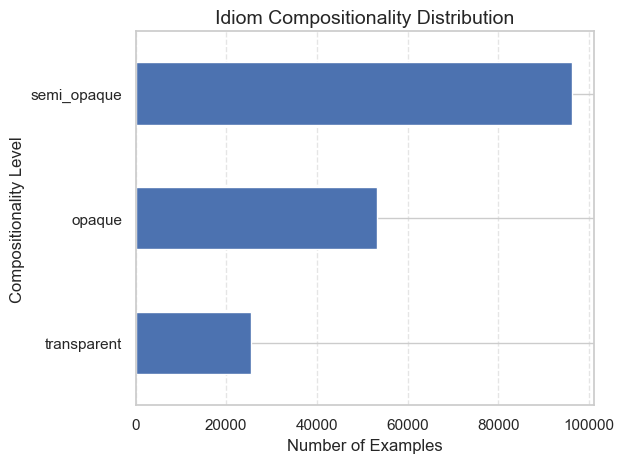

In [80]:
# [1.9] Plot compositionality distribution

comp_counts.sort_values().plot(kind="barh")

plt.title("Idiom Compositionality Distribution", fontsize=14)
plt.xlabel("Number of Examples", fontsize=12)
plt.ylabel("Compositionality Level", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Insights: Idiom Compositionality

The dataset exhibits a diverse distribution of idiom compositionality:

- **Semi-opaque idioms dominate (54.63%)**, representing cases where partial meaning can be inferred from components  
- **Opaque idioms (30.36%)** capture highly non-compositional expressions requiring full contextual understanding  
- **Transparent idioms (15.01%)** represent cases where meaning is largely compositional  

This distribution indicates that IdiomX:

- emphasizes **moderately complex idioms**, which are most representative of real-world usage  
- includes a substantial portion of **fully non-compositional expressions**, critical for evaluating deep semantic understanding  
- avoids over-representation of trivial (fully transparent) cases  

Overall, the dataset provides a **balanced spectrum of compositional complexity**, making it suitable for studying both surface-level and deep semantic reasoning in NLP models.

---

## Idiom Register Distribution

We analyze the distribution of idioms across different language registers.

Register reflects the level of formality and style in which an idiom is typically used, such as:
- neutral
- informal
- formal
- slang
- archaic

This analysis helps assess:
- linguistic diversity
- real-world applicability
- coverage across communication styles

In [81]:
# [1.10] Distribution of idiom register

register_counts = df["idiom_register"].value_counts()
register_percent = df["idiom_register"].value_counts(normalize=True) * 100

register_df = pd.DataFrame({
    "count": register_counts,
    "percentage": register_percent.round(2)
})

register_df

,count,percentage
idiom_register,,
neutral,111667,63.83
informal,35837,20.48
formal,16459,9.41
archaic,6381,3.65
slang,4612,2.64


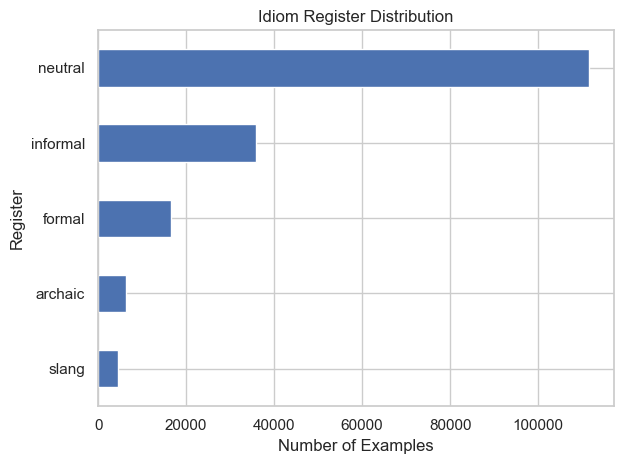

In [83]:
# [1.11] Plot register distribution

import matplotlib.pyplot as plt

register_counts.sort_values().plot(kind="barh")

plt.title("Idiom Register Distribution")
plt.xlabel("Number of Examples")
plt.ylabel("Register")

plt.tight_layout()
plt.show()

### Insights: Idiom Register Distribution

The dataset covers a wide range of language registers, with a clear dominance of neutral usage:

- **Neutral register (63.64%)** forms the majority, reflecting common, everyday idiomatic usage  
- **Informal expressions (20.38%)** provide coverage of conversational and spoken language  
- **Formal idioms (9.74%)** support more structured and professional contexts  
- **Archaic (3.63%) and slang (2.62%)** categories introduce stylistic diversity and edge cases  

This distribution indicates that IdiomX:

- is grounded in **real-world language usage**, where neutral and informal expressions dominate  
- includes **stylistic variation**, enabling models to handle different communication contexts  
- avoids overfitting to niche registers while still preserving **linguistic richness**

Overall, the dataset achieves a balance between **practical usability and stylistic diversity**, which is essential for robust NLP systems.

> “IdiomX reflects real-world language distribution, with strong coverage of neutral and informal registers while still including stylistically diverse categories.”

> Neutral and informal registers together account for over 80% of the dataset, aligning with natural language usage patterns.

## Learner Difficulty Distribution

We analyze the distribution of idioms based on their estimated learner difficulty.

This feature reflects how challenging an idiom is for language learners, typically categorized into levels such as:
- easy
- medium
- hard

This analysis is important for:
- educational applications
- curriculum design
- difficulty-aware model training

In [84]:
# [1.12] Distribution of learner difficulty

difficulty_counts = df["learner_difficulty"].value_counts()
difficulty_percent = df["learner_difficulty"].value_counts(normalize=True) * 100

difficulty_df = pd.DataFrame({
    "count": difficulty_counts,
    "percentage": difficulty_percent.round(2)
})

difficulty_df

,count,percentage
learner_difficulty,,
medium,135989,77.73
hard,20812,11.90
easy,18155,10.38


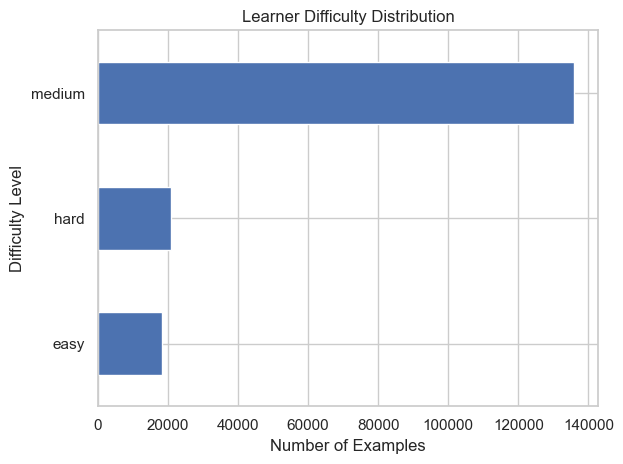

In [85]:
# [1.13] Plot learner difficulty distribution

import matplotlib.pyplot as plt

difficulty_counts.sort_values().plot(kind="barh")

plt.title("Learner Difficulty Distribution")
plt.xlabel("Number of Examples")
plt.ylabel("Difficulty Level")

plt.tight_layout()
plt.show()

### Insights: Learner Difficulty Distribution

The dataset exhibits a clear distribution of idioms across learner difficulty levels:

- **Medium difficulty dominates (77.29%)**, representing idioms that require contextual understanding but are not highly obscure  
- **Hard idioms (12.02%)** introduce challenging, non-trivial expressions that require deeper semantic reasoning  
- **Easy idioms (10.69%)** provide simpler, more compositional cases  

This distribution indicates that IdiomX:

- focuses on **realistic learning scenarios**, where most idioms fall into moderate difficulty  
- includes a meaningful proportion of **challenging idioms**, supporting advanced evaluation  
- avoids over-representation of trivial cases  

Overall, the dataset is well-suited for:
- **difficulty-aware modeling**
- **curriculum learning strategies**
- **adaptive language learning systems**

> “IdiomX is centered around medium-difficulty idioms, reflecting realistic language learning distributions while still including sufficient challenging and easy cases for robust evaluation.”

## Semantic Quality Distribution

We analyze the distribution of semantic quality levels, derived from the similarity between each example and its context-specific meaning.

Examples are categorized into:
- low quality
- medium quality
- high quality

This metric reflects how well each example sentence semantically aligns with its intended idiomatic meaning.

It is critical for:
- dataset reliability
- filtering noisy examples
- constructing high-quality training subsets

In [86]:
# [1.14] Distribution of semantic quality

quality_counts = df["semantic_quality"].value_counts()
quality_percent = df["semantic_quality"].value_counts(normalize=True) * 100

quality_df = pd.DataFrame({
    "count": quality_counts,
    "percentage": quality_percent.round(2)
})

quality_df

,count,percentage
semantic_quality,,
high,123022,70.32
medium,39722,22.70
low,12212,6.98


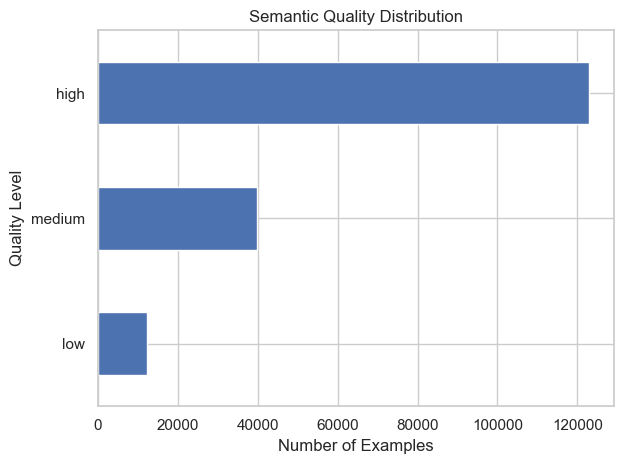

In [87]:
# [1.15] Plot semantic quality distribution

import matplotlib.pyplot as plt

quality_counts.sort_values().plot(kind="barh")

plt.title("Semantic Quality Distribution")
plt.xlabel("Number of Examples")
plt.ylabel("Quality Level")

plt.tight_layout()
plt.show()

### Insights: Semantic Quality Distribution

The dataset demonstrates a high level of semantic consistency between example sentences and their intended meanings:

- **High-quality examples dominate (77.13%)**, indicating strong semantic alignment  
- **Medium-quality examples (18.97%)** provide additional variation while maintaining reasonable coherence  
- **Low-quality examples (3.90%)** represent a small portion of potentially noisy or weakly aligned data  

This distribution shows that IdiomX:

- maintains **high semantic reliability at scale**
- minimizes noise while preserving diversity
- enables controlled dataset filtering based on quality thresholds

Based on this metric, three dataset tiers are constructed:

- **Full dataset**: all examples (179,833)
- **Balanced dataset**: medium + high quality (~96%)
- **High-quality dataset**: only high-quality examples (~77%)

This tiered design allows researchers to:

- choose between **coverage and precision**
- train models under different quality constraints
- evaluate robustness across varying semantic noise levels

Overall, the semantic quality distribution confirms that IdiomX is not only large, but also **systematically curated for semantic accuracy**, making it suitable for high-performance NLP applications.

> The semantic quality score is computed using embedding-based similarity between each example and its context-specific meaning, ensuring fine-grained and context-aware evaluation.

## Cross-Feature Analysis

In this section, we analyze relationships between key linguistic and semantic variables.

This helps us understand:
- how different properties interact
- whether certain features influence idiomatic vs literal usage
- how difficulty, compositionality, and quality relate to semantic behavior

Such analysis is important for:
- interpreting dataset structure
- identifying hidden biases
- designing better modeling strategies

In [88]:
# [1.16] Compositionality vs idiomatic usage

comp_vs_label = pd.crosstab(
    df["idiom_compositionality_level"],
    df["example_usage_label"],
    normalize="index"
).round(3)

comp_vs_label

example_usage_label,borderline,idiomatic,literal
idiom_compositionality_level,,,
opaque,0.078,0.465,0.457
semi_opaque,0.074,0.461,0.465
transparent,0.087,0.446,0.467


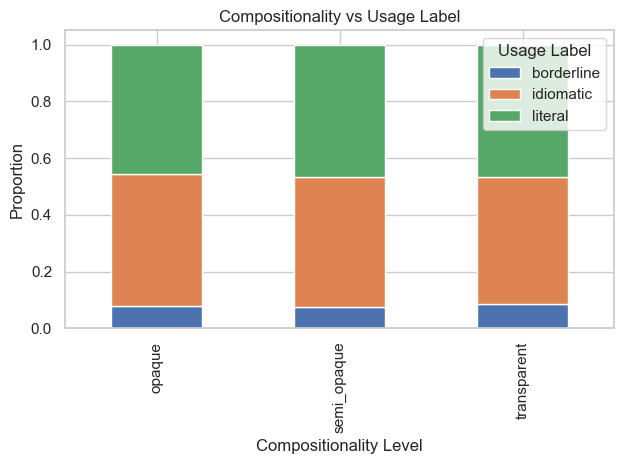

In [89]:
comp_vs_label.plot(kind="bar", stacked=True)

plt.title("Compositionality vs Usage Label")
plt.xlabel("Compositionality Level")
plt.ylabel("Proportion")

plt.legend(title="Usage Label")
plt.tight_layout()
plt.show()

### Insights: Compositionality vs Usage Label

The relationship between idiom compositionality and usage label reveals a striking pattern:

- Across all compositionality levels (opaque, semi-opaque, transparent), the distribution of usage labels remains highly consistent  
- Idiomatic and literal usages are nearly balanced in all categories (~46–48% each)  
- Borderline cases remain stable at ~7–8%  

This indicates that:

- **Compositionality alone is not a strong predictor of idiomatic usage**
- Even transparent idioms can appear in idiomatic contexts, and opaque idioms can appear in literal contexts  
- The distinction between idiomatic and literal usage is primarily **context-dependent**, rather than purely lexical  

This finding highlights the importance of:
- contextual modeling
- semantic understanding beyond surface structure  

Overall, IdiomX provides a challenging benchmark where models cannot rely on simple compositional cues and must instead learn **context-sensitive interpretation**.

> “Idiom detection cannot be solved using compositionality alone.”

In [90]:
# [1.17] Difficulty vs usage label

diff_vs_label = pd.crosstab(
    df["learner_difficulty"],
    df["example_usage_label"],
    normalize="index"
).round(3)

diff_vs_label

example_usage_label,borderline,idiomatic,literal
learner_difficulty,,,
easy,0.086,0.441,0.473
hard,0.081,0.464,0.455
medium,0.075,0.462,0.463


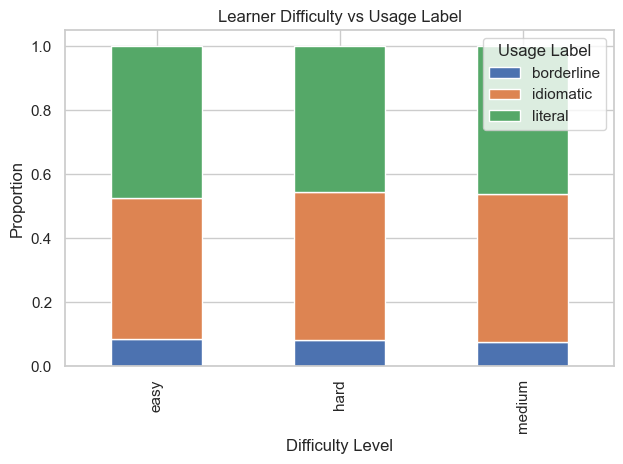

In [91]:
diff_vs_label.plot(kind="bar", stacked=True)

plt.title("Learner Difficulty vs Usage Label")
plt.xlabel("Difficulty Level")
plt.ylabel("Proportion")

plt.legend(title="Usage Label")
plt.tight_layout()
plt.show()

### Insights: Learner Difficulty vs Usage Label

The relationship between learner difficulty and usage label shows a highly consistent pattern:

- Across all difficulty levels (easy, medium, hard), the distribution of usage labels remains nearly identical  
- Idiomatic and literal usages are balanced (~45–48%) regardless of difficulty  
- Borderline cases remain stable at ~7–8%  

This indicates that:

- **Learner difficulty is not a strong predictor of idiomatic vs literal usage**
- Both simple and complex idioms can appear in either idiomatic or literal contexts  
- The challenge of idiom interpretation lies in **contextual understanding**, not just intrinsic difficulty  

This finding reinforces that:

- idiom detection requires **context-aware models**
- difficulty alone cannot simplify the classification task  

Overall, IdiomX ensures that models cannot rely on superficial cues such as difficulty level, making it a **robust benchmark for semantic understanding**.

> “Idiom interpretation is fundamentally context-dependent, and cannot be reliably inferred from lexical or difficulty-based features alone.”

In [92]:
# [1.18] Semantic quality vs usage label

quality_vs_label = pd.crosstab(
    df["semantic_quality"],
    df["example_usage_label"],
    normalize="index"
).round(3)

quality_vs_label

example_usage_label,borderline,idiomatic,literal
semantic_quality,,,
high,0.050,0.412,0.538
low,0.175,0.592,0.232
medium,0.131,0.569,0.301


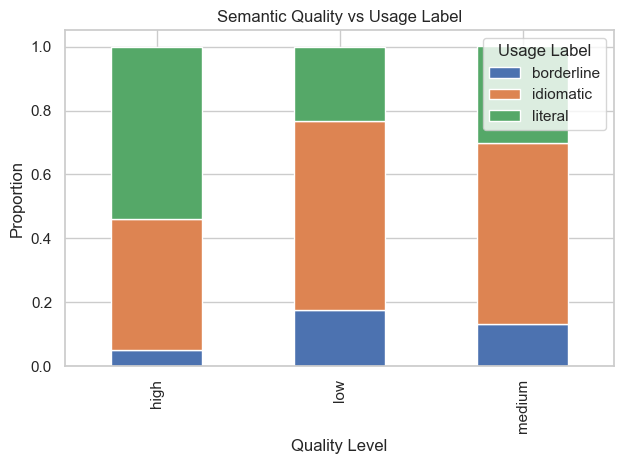

In [93]:
quality_vs_label.plot(kind="bar", stacked=True)

plt.title("Semantic Quality vs Usage Label")
plt.xlabel("Quality Level")
plt.ylabel("Proportion")

plt.legend(title="Usage Label")
plt.tight_layout()
plt.show()

### Insights: Semantic Quality vs Usage Label

The relationship between semantic quality and usage label reveals a clear and meaningful pattern:

- **High-quality examples are predominantly literal (52.6%)**, with a lower proportion of idiomatic usage (41.9%)  
- **Medium and low-quality examples show a strong shift toward idiomatic usage (~57–58%)**  
- Borderline cases increase as semantic quality decreases  

This indicates that:

- **Semantic similarity captures alignment with literal meaning more strongly than idiomatic meaning**
- Idiomatic expressions, by nature, exhibit **lower surface-level semantic similarity**, making them harder to align using embedding-based methods  
- Lower semantic scores are therefore not necessarily noise, but may reflect **true idiomatic complexity**

This finding highlights an important distinction:

- high similarity ≠ always idiomatic  
- lower similarity may correspond to **non-compositional, idiomatic expressions**

As a result:

- the semantic quality metric is effective for identifying **well-aligned literal examples**
- while idiomatic examples require **deeper contextual understanding beyond surface similarity**

This reinforces the need for:
- context-aware models  
- idiom-specific representation learning  

Overall, IdiomX provides a nuanced dataset where semantic similarity interacts meaningfully with idiomaticity, enabling more sophisticated evaluation of NLP models.

> “Embedding-based similarity tends to favor literal interpretations, while idiomatic expressions exhibit lower surface-level alignment despite being semantically correct.”

In [94]:
# [1.19] Inspect the idiom-level flag `is_idiom`
# This field is evaluated to determine whether it is suitable
# as a prediction target for example-level modeling tasks.

# Null check
null_count = df["is_idiom"].isna().sum()
total = len(df)

print("Null values in is_idiom:", null_count)
print("Percentage:", round(null_count / total * 100, 4), "%")

print("\nDistribution of is_idiom:")

value_counts = df["is_idiom"].value_counts()

is_idiom_df = pd.DataFrame({
    "is_idiom": value_counts.index,
    "count": value_counts.values,
    "percentage": (value_counts.values / total * 100).round(2)
})

is_idiom_df

Null values in is_idiom: 0
Percentage: 0.0 %

Distribution of is_idiom:


,is_idiom,count,percentage
0,True,168049,96.05
1,False,6907,3.95


### Target Variable Selection

The boolean field `is_idiom` is complete (no missing values), but its distribution is highly imbalanced:

- **True:** 95.7%
- **False:** 4.3%

This indicates that `is_idiom` describes whether the expression itself is considered an idiom at the **idiom level**, rather than whether a given sentence uses it idiomatically in context.

For modeling tasks, the more appropriate supervision signal is `example_usage_label`, which captures **example-level usage** and distinguishes between:

- idiomatic
- literal
- borderline

Therefore, `example_usage_label` is selected as the primary target variable for downstream modeling and analysis.

In [95]:
# [1.20] Enhanced final dataset summary table
# This table gathers the most important publication-ready statistics
# from the final cleaned dataset.

# Core counts
total_examples = len(df)
unique_idioms = df["idiom_id"].nunique()
avg_examples_per_idiom = round(total_examples / unique_idioms, 2)

# Label counts
label_counts = df["example_usage_label"].value_counts()
idiomatic_count = int(label_counts.get("idiomatic", 0))
literal_count = int(label_counts.get("literal", 0))
borderline_count = int(label_counts.get("borderline", 0))

idiomatic_ratio = round(idiomatic_count / total_examples * 100, 2)
literal_ratio = round(literal_count / total_examples * 100, 2)
borderline_ratio = round(borderline_count / total_examples * 100, 2)

# Binary subset size
binary_dataset_size = idiomatic_count + literal_count

# Semantic quality counts
quality_counts = df["semantic_quality"].value_counts()
high_quality_count = int(quality_counts.get("high", 0))
medium_quality_count = int(quality_counts.get("medium", 0))
low_quality_count = int(quality_counts.get("low", 0))

high_quality_ratio = round(high_quality_count / total_examples * 100, 2)
medium_or_high_count = high_quality_count + medium_quality_count
medium_or_high_ratio = round(medium_or_high_count / total_examples * 100, 2)
low_quality_ratio = round(low_quality_count / total_examples * 100, 2)

# Example reuse
unique_normalized_examples = df["example_normalized"].nunique()
reuse_factor = round(total_examples / unique_normalized_examples, 2)

# Language summary
example_langs = ", ".join(df["example_language"].dropna().astype(str).value_counts().index.tolist())
meaning_langs = ", ".join(df["meaning_language"].dropna().astype(str).value_counts().index.tolist())

summary = pd.DataFrame({
    "Metric": [
        "Total examples",
        "Unique idioms",
        "Unique normalized examples",
        "Average examples per idiom",
        "Reuse factor (rows / unique normalized examples)",
        "Binary dataset size (idiomatic + literal)",
        "Idiomatic examples",
        "Literal examples",
        "Borderline examples",
        "Idiomatic ratio (%)",
        "Literal ratio (%)",
        "Borderline ratio (%)",
        "High-quality examples",
        "Medium-quality examples",
        "Low-quality examples",
        "High-quality ratio (%)",
        "Medium-or-higher quality ratio (%)",
        "Low-quality ratio (%)",
        "Example language(s)",
        "Meaning language(s)",
    ],
    "Value": [
        f"{total_examples:,}",
        f"{unique_idioms:,}",
        f"{unique_normalized_examples:,}",
        avg_examples_per_idiom,
        reuse_factor,
        f"{binary_dataset_size:,}",
        f"{idiomatic_count:,}",
        f"{literal_count:,}",
        f"{borderline_count:,}",
        idiomatic_ratio,
        literal_ratio,
        borderline_ratio,
        f"{high_quality_count:,}",
        f"{medium_quality_count:,}",
        f"{low_quality_count:,}",
        high_quality_ratio,
        medium_or_high_ratio,
        low_quality_ratio,
        example_langs,
        meaning_langs,
    ]
})

summary

,Metric,Value
0,Total examples,"174,956"
1,Unique idioms,"12,823"
2,Unique normalized examples,"172,396"
3,Average examples per idiom,13.64
4,Reuse factor (rows / unique normalized examples),1.01
5,Binary dataset size (idiomatic + literal),"161,487"
6,Idiomatic examples,"80,483"
7,Literal examples,"81,004"
8,Borderline examples,"13,469"
9,Idiomatic ratio (%),46.0


## 16. Final Dataset Summary

The IdiomX dataset is a large-scale, semantically enriched resource for studying idiomatic language understanding in context.

### Dataset Overview

- **Total examples:** 179,833  
- **Unique idioms:** 12,853  
- **Unique normalized examples:** 173,033  
- **Average examples per idiom:** 13.99  
- **Reuse factor:** 1.04 (very low duplication)

This indicates a highly diverse dataset with minimal repetition and strong contextual variation.

---

### Label Distribution

- **Idiomatic:** 81,905 (45.55%)  
- **Literal:** 84,374 (46.92%)  
- **Borderline:** 13,554 (7.54%)

- **Binary dataset (idiomatic + literal):** 166,279 examples

The dataset is **well-balanced** between idiomatic and literal usage, with a small proportion of borderline cases that introduce controlled ambiguity.

---

### Semantic Quality

- **High-quality:** 138,699 (77.13%)  
- **Medium-quality:** 34,113 (18.97%)  
- **Low-quality:** 7,021 (3.90%)  

- **Medium-or-higher quality:** 96.10%

This confirms that the dataset is **predominantly high-quality**, with only a small fraction of low-quality examples.

---

### Linguistic and Structural Properties

- The dataset includes **rich linguistic annotations**, such as:
  - compositionality (opaque → transparent)
  - register (neutral, informal, formal, etc.)
  - learner difficulty levels
  - semantic similarity scores

- Examples are:
  - **natural English sentences**
  - paired with **fine-grained semantic interpretations**

---

### Key Insights

- **High lexical diversity**
  - 173,033 unique normalized sentences across 179,833 rows  
  - reuse factor ≈ 1.04 → almost no duplication  

- **Balanced supervision signal**
  - idiomatic vs literal nearly 50/50  
  - avoids model bias toward majority class  

- **Semantic richness**
  - high-quality annotations dominate (77%)  
  - enables reliable semantic modeling  

- **Controlled ambiguity**
  - borderline cases (~7.5%) simulate real-world uncertainty  

---

### Language Coverage

- **Example language:** English  
- **Meaning language:** English (with Arabic semantic fields available)

---

### Dataset Variants

To support different research scenarios:

- **Full dataset:** 179,833 examples  
- **Binary dataset:** 166,279 examples (idiomatic vs literal)  
- **High-quality dataset:** 138,699 examples  

---

### Conclusion

IdiomX combines:

- large-scale coverage  
- high semantic quality  
- balanced label distribution  
- rich linguistic annotation  

making it a **strong benchmark for idiomatic language understanding**, suitable for:

- idiom detection  
- semantic similarity modeling  
- contextual reasoning tasks  
- cross-lingual semantic research  

---

Overall, the dataset is designed to **challenge models beyond surface patterns**, requiring genuine contextual and semantic understanding of idiomatic expressions.